# The Perceptron: Foundation of Neural Networks

The perceptron is the basic building block of neural networks, inspired by biological neurons. It's a single-layer neural network that performs binary classification by computing a weighted sum of inputs and applying a threshold.

## Key Components

- **Inputs**: Features or data points
- **Weights**: Learnable parameters that determine the importance of each input
- **Bias**: An offset term that shifts the decision boundary
- **Activation Function**: Typically a step function for binary classification

## Mathematical Representation

For inputs $x_1, x_2, \dots, x_n$, weights $w_1, w_2, \dots, w_n$, and bias $b$:

$$
z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b
$$

$$
\hat{y} = 
\begin{cases} 
1 & \text{if } z \geq 0 \\
0 & \text{if } z < 0 
\end{cases}
$$

## Loss Function

For training, we need a loss function to measure how well the perceptron performs. Common choices include:

- **Mean Squared Error (MSE)** for regression: $L = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$
- **Binary Cross-Entropy** for binary classification: $L = -\frac{1}{n} \sum_{i=1}^n [y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i)]$

## Back-Propagation

Back-propagation is the algorithm used to train neural networks by computing gradients of the loss function with respect to the weights and updating them to minimize the loss.

1. **Forward Pass**: Compute predictions
2. **Compute Loss**: Calculate how wrong the predictions are
3. **Backward Pass**: Compute gradients using the chain rule
4. **Update Weights**: Adjust weights in the direction that reduces loss

$$
w \leftarrow w - \eta \frac{\partial L}{\partial w}
$$

$$
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

Where $\eta$ is the learning rate.

This simple perceptron forms the basis for more complex neural networks like multi-layer perceptrons (MLPs).

In [4]:
pip install torch matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Simple Linear Regression Example: y = 2*x1 + 3*x2 + 1
# We'll create a small dataset and train a perceptron to learn these parameters

# 1. Create synthetic dataset
torch.manual_seed(42)  # For reproducibility
X = torch.randn(100, 2)  # 100 samples, 2 features
true_weights = torch.tensor([2.0, 3.0])
true_bias = 1.0
y = X @ true_weights + true_bias + 0.1 * torch.randn(100)  # Add some noise

In [6]:
# 2. Define the Perceptron (Single Neuron for Regression)
class Perceptron(nn.Module):
    def __init__(self, input_size):
        super(Perceptron, self).__init__()
        self.linear = nn.Linear(input_size, 1)  # One output for regression

    def forward(self, x):
        return self.linear(x)

# 3. Initialize model, loss, and optimizer
model = Perceptron(input_size=2)
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [7]:
# 4. Training loop
epochs = 1000
losses = []

print("Training the Perceptron...")
print(f"True weights: {true_weights}, True bias: {true_bias}")
print("Initial weights:", model.linear.weight.data, "Initial bias:", model.linear.bias.data)

for epoch in range(epochs):
    # Forward pass
    predictions = model(X)
    loss = criterion(predictions.squeeze(), y)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

print("\nFinal weights:", model.linear.weight.data, "Final bias:", model.linear.bias.data)
print(f"Learned close to true values: weights {model.linear.weight.data.squeeze()}, bias {model.linear.bias.data.item():.4f}")

Training the Perceptron...
True weights: tensor([2., 3.]), True bias: 1.0
Initial weights: tensor([[-0.5378, -0.5673]]) Initial bias: tensor([0.3518])
Epoch 0, Loss: 20.0602
Epoch 100, Loss: 0.3653
Epoch 200, Loss: 0.0203
Epoch 300, Loss: 0.0089
Epoch 400, Loss: 0.0082
Epoch 500, Loss: 0.0081
Epoch 600, Loss: 0.0081
Epoch 700, Loss: 0.0081
Epoch 800, Loss: 0.0081
Epoch 900, Loss: 0.0081

Final weights: tensor([[2.0097, 2.9986]]) Final bias: tensor([1.0209])
Learned close to true values: weights tensor([2.0097, 2.9986]), bias 1.0209


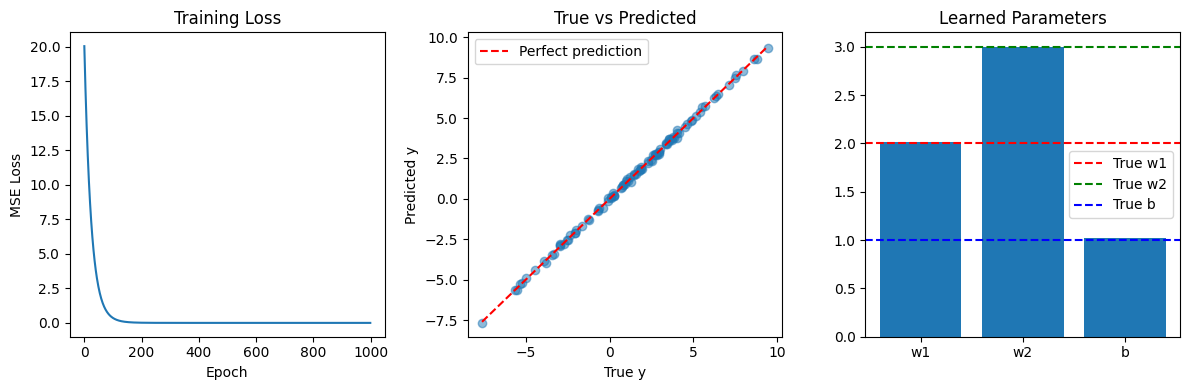

In [8]:
# 5. Visualize the results
plt.figure(figsize=(12, 4))

# Plot loss over time
plt.subplot(1, 3, 1)
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

# Plot true vs predicted
plt.subplot(1, 3, 2)
with torch.no_grad():
    pred = model(X).squeeze()
plt.scatter(y.numpy(), pred.numpy(), alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('True vs Predicted')
plt.legend()

# Plot weight convergence
plt.subplot(1, 3, 3)
weight_history = []
bias_history = []
for epoch in range(0, epochs, 10):  # Sample every 10 epochs
    # This is a simplified version - in practice, you'd log during training
    pass
# For demonstration, just show final values
plt.bar(['w1', 'w2', 'b'], [model.linear.weight.data[0,0].item(), model.linear.weight.data[0,1].item(), model.linear.bias.data.item()])
plt.axhline(y=true_weights[0].item(), color='r', linestyle='--', label='True w1')
plt.axhline(y=true_weights[1].item(), color='g', linestyle='--', label='True w2')
plt.axhline(y=true_bias, color='b', linestyle='--', label='True b')
plt.title('Learned Parameters')
plt.legend()

plt.tight_layout()
plt.show()